# Deliverable 5 — Network Growth Analysis Over Time

Self-contained notebook. Rebuilds the co-watch network, builds yearly cumulative
snapshots, tracks structural metrics over time, identifies the percolation
threshold, and compares early vs late degree distributions.

In [55]:
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# python-louvain exports community.best_partition; a different 'community' pkg may be installed
try:
    import community as _c
    _ = _c.best_partition   # raises AttributeError if wrong package
except (ImportError, AttributeError):
    print('Installing python-louvain...')
    pip_install('python-louvain')

try:
    import powerlaw
except ImportError:
    print('Installing powerlaw...')
    pip_install('powerlaw')

try:
    import seaborn
except ImportError:
    pip_install('seaborn')

print('All packages ready.')

All packages ready.


In [56]:
import warnings
warnings.filterwarnings('ignore')

import os, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
from scipy import sparse, stats
from scipy.sparse import csr_matrix
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import normalized_mutual_info_score
from itertools import combinations

try:
    import community as community_louvain
    _ = community_louvain.best_partition  # verify it's python-louvain
    HAVE_LOUVAIN = True
except (ImportError, AttributeError):
    HAVE_LOUVAIN = False
    print('python-louvain unavailable — will use NetworkX greedy modularity')

try:
    import powerlaw as pl_lib
    HAVE_POWERLAW = True
except ImportError:
    HAVE_POWERLAW = False

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

# --- Auto-detect dataset path (works on Kaggle regardless of dataset slug) ---
_candidates = [
    '/kaggle/input/datasets/shamiksinha/anime-dataset-nsproject',
    '/kaggle/input/anime-dataset-nsproject',
    '/kaggle/input/anime-recommendation-database',
]
DATA_PATH = "Anime_Recommendation_Database"
# for _c in _candidates:
#     if os.path.isfile(os.path.join(_c, 'anime.csv')):
#         DATA_PATH = _c
#         break
# if DATA_PATH is None:
#     _hits = glob.glob('/kaggle/input/**/anime.csv', recursive=True)
#     if _hits:
#         DATA_PATH = os.path.dirname(_hits[0])
# if DATA_PATH is None:
#     raise FileNotFoundError(
#         "Could not find anime.csv under /kaggle/input/.\n"
#         "Make sure the dataset is attached to this notebook. "
#         "Files found under /kaggle/input/: " + str(os.listdir('/kaggle/input/'))
#     )

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

STATUS_MAP = {1: 'Watching', 2: 'Completed', 3: 'On Hold', 4: 'Dropped', 6: 'Plan to Watch'}

print('Imports done.')
print(f'NetworkX version: {nx.__version__}')
print(f'Louvain available: {HAVE_LOUVAIN}')
print(f'powerlaw available: {HAVE_POWERLAW}')
print(f'Data path auto-detected: {DATA_PATH}')
print(f'Files: {os.listdir(DATA_PATH)}')

Imports done.
NetworkX version: 3.2.1
Louvain available: True
powerlaw available: True
Data path auto-detected: Anime_Recommendation_Database
Files: ['anime.csv', 'animelist.csv', 'anime_with_synopsis.csv', 'html folder', 'rating_complete.csv', 'watching_status.csv']


## Data Loading & Preprocessing

We load two main files:
- **`anime.csv`** — metadata for each anime (title, genres, type, air date, scores, member counts)
- **`animelist.csv`** — 109M+ user–anime interaction rows (user_id, anime_id, rating, watching_status, watched_episodes)

Because `animelist.csv` is very large, we sample users with `user_id ≤ 9999`. Since the file is sorted by `user_id`, we can stop reading early, giving us ~3M rows covering ~10,000 users — a large, representative sample.

In [57]:
# Load anime metadata
anime_df = pd.read_csv(os.path.join(DATA_PATH, 'anime.csv'), low_memory=False)
anime_df.rename(columns={'MAL_ID': 'anime_id'}, inplace=True)

# Parse air year from 'Aired' column
def parse_year(aired_str):
    if pd.isna(aired_str) or aired_str == 'Unknown':
        return np.nan
    import re
    match = re.search(r'(\d{4})', str(aired_str))
    return int(match.group(1)) if match else np.nan

anime_df['air_year'] = anime_df['Aired'].apply(parse_year)

# Convert score to numeric
anime_df['Score'] = pd.to_numeric(anime_df['Score'], errors='coerce')
anime_df['Members'] = pd.to_numeric(anime_df['Members'], errors='coerce')

# Build quick lookup: anime_id -> name, genres
anime_lookup = anime_df.set_index('anime_id')[['Name','Genres','Type','air_year','Score','Members']]

print(f'Anime metadata loaded: {anime_df.shape[0]} anime titles')
print(f'Year range (non-null): {int(anime_df["air_year"].min())} – {int(anime_df["air_year"].max())}')
print(f'Genres sample: {anime_df["Genres"].dropna().iloc[0]}')
anime_df[['anime_id','Name','Score','Genres','Type','air_year','Members']].head(5)

Anime metadata loaded: 17562 anime titles
Year range (non-null): 1917 – 2022
Genres sample: Action, Adventure, Comedy, Drama, Sci-Fi, Space


,anime_id,Name,Score,Genres,Type,air_year,Members
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,1998.0,1251960
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Movie,2001.0,273145
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",TV,1998.0,558913
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",TV,2002.0,94683
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",TV,2004.0,13224


In [58]:
# Load animelist — two sampling strategies available:
#
#   FAST (default):  users 0–9,999 → ~3M rows, loads in ~10s
#                    Bias: early MAL users, skews toward older anime & power users
#
#   REPRESENTATIVE:  modulo-hash sample (every 30th user_id across full file) → ~3.6M rows
#                    reads all 109M rows (~3-5 min on Kaggle), but spreads evenly over all users
#
# Set REPRESENTATIVE_SAMPLE = True to use the slower but unbiased version.

REPRESENTATIVE_SAMPLE = True   # flip to True for unbiased sampling

CHUNK = 500_000
chunks = []

if not REPRESENTATIVE_SAMPLE:
    SAMPLE_MAX_UID = 9999
    print(f'Loading animelist (fast mode: users 0–{SAMPLE_MAX_UID})...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] <= SAMPLE_MAX_UID]
        chunks.append(sub)
        if chunk['user_id'].max() > SAMPLE_MAX_UID:
            break
else:
    MODULO = 10   # keep every 30th user_id → ~1/30 of all users, spread across full range
    print(f'Loading animelist (representative mode: user_id % {MODULO} == 0, reads full file)...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] % MODULO == 0]
        chunks.append(sub)

animelist = pd.concat(chunks, ignore_index=True)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'Shape: {animelist.shape}')
print(f'Unique users:  {animelist["user_id"].nunique():,}')
print(f'Unique anime:  {animelist["anime_id"].nunique():,}')

print('\nWatching status breakdown:')
status_counts = animelist['watching_status'].map(STATUS_MAP).value_counts()
for status, count in status_counts.items():
    print(f'  {status:<18}: {count:>9,} rows ({100*count/len(animelist):.1f}%)')

Loading animelist (representative mode: user_id % 10 == 0, reads full file)...
Loaded in 23.9s
Shape: (11002813, 5)
Unique users:  32,575
Unique anime:  17,551

Watching status breakdown:
  Completed         : 6,860,393 rows (62.4%)
  Plan to Watch     : 2,791,683 rows (25.4%)
  Watching          :   518,253 rows (4.7%)
  Dropped           :   453,575 rows (4.1%)
  On Hold           :   378,892 rows (3.4%)


## Working DataFrames — Column Reference

After loading, we work with two core DataFrames throughout the notebook:

---

### `anime_df` — Anime Metadata Table
Shape: ~17,562 rows × 36 columns. Each row is one anime title.

| Column | Type | Description |
|--------|------|-------------|
| `anime_id` | int | Unique anime ID (renamed from `MAL_ID`). Primary key — used to join with `animelist`. |
| `Name` | str | Canonical romanized title |
| `Score` | float | Weighted average community rating (1–10). `NaN` if not enough votes. |
| `Genres` | str | Comma-separated genre tags, e.g. `"Action, Adventure, Comedy"`. We split on `,` to get individual genres. |
| `Type` | str | Format of the release: `TV`, `Movie`, `OVA`, `ONA`, `Special`, `Music` |
| `Episodes` | str | Episode count (`"Unknown"` for ongoing/unknown) |
| `Aired` | str | Raw air date string, e.g. `"Apr 3, 1998 to Apr 24, 1999"`. We parse the first 4-digit year from this → `air_year`. |
| `Members` | int | Total number of MAL users who have this title in any list — proxy for popularity |
| `Completed` | int | Aggregate count of users who marked it completed |
| `Dropped` | int | Aggregate count of users who dropped it |
| `Watching` | int | Aggregate count currently watching |
| `Plan to Watch` | int | Aggregate count planning to watch |
| `Favorites` | int | Number of users who marked it as a favourite |
| `Score-1` … `Score-10` | float | Distribution of individual ratings (how many users gave each score) |
| `air_year` *(derived)* | float | Parsed 4-digit start year from `Aired`. Used in Deliverable 5 for temporal snapshots. |

---

### `animelist` — User Interaction Log (sampled)
Shape: ~3M rows × 5 columns. Each row is one user's record for one anime.

| Column | Type | Description |
|--------|------|-------------|
| `user_id` | int | Anonymous user identifier. We sample users `0–9999` to keep the dataset tractable. |
| `anime_id` | int | Links to `anime_df`. The anime this row refers to. |
| `rating` | int | User's personal rating (1–10). `0` means the user didn't leave a rating. |
| `watching_status` | int | Current engagement status: `1` Watching · `2` **Completed** · `3` On Hold · `4` **Dropped** · `6` **Plan to Watch** |
| `watched_episodes` | int | Number of episodes the user has watched so far |

> **How these two tables connect:** `animelist.anime_id` → `anime_df.anime_id`. The `animelist` table tells us *who* watched *what* and *how*, while `anime_df` tells us the properties of each title. Most of the network construction work happens on `animelist`, and `anime_df` provides node attributes (genre, score, year, etc.).

## Prerequisite — Co-Watch Network (from Deliverable 1)
The cell below rebuilds the co-watch network `G` (with anime metadata including
`air_year`) that D5 temporal snapshot analysis uses.

In [59]:
# --- Build co-watch network ---
# TOP_N_ANIME   = 500   # restrict to most-completed anime
# MIN_COWATCH   = 1000     # minimum co-completions to add edge

TOP_N_ANIME   = 1000   # restrict to most-completed anime
MIN_COWATCH   = 2000   # minimum co-completions to add edge

# Filter completed interactions
completed = animelist[animelist['watching_status'] == 2][['user_id','anime_id']].copy()

# Keep only top-N most completed anime
top_anime_ids = completed['anime_id'].value_counts().head(TOP_N_ANIME).index
completed = completed[completed['anime_id'].isin(top_anime_ids)]

# Also filter: keep users who completed at least 3 of the top anime
user_counts = completed.groupby('user_id')['anime_id'].count()
active_users = user_counts[user_counts >= 3].index
completed = completed[completed['user_id'].isin(active_users)]

print(f'Filtered completed interactions: {len(completed):,}')
print(f'Users in this set: {completed["user_id"].nunique():,}')
print(f'Anime in this set: {completed["anime_id"].nunique():,}')

# Encode indices
u_enc = LabelEncoder(); a_enc = LabelEncoder()
u_idx = u_enc.fit_transform(completed['user_id'])
a_idx = a_enc.fit_transform(completed['anime_id'])
n_users = len(u_enc.classes_); n_anime = len(a_enc.classes_)

# Sparse user-anime matrix
M = csr_matrix((np.ones(len(u_idx)), (u_idx, a_idx)), shape=(n_users, n_anime))

# Co-occurrence via matrix multiplication
C = (M.T @ M).toarray().astype(int)
np.fill_diagonal(C, 0)

# Build graph
rows, cols = np.where(np.triu(C, k=1) >= MIN_COWATCH)
anime_ids_arr = a_enc.classes_

G = nx.Graph()
G.add_nodes_from(anime_ids_arr)
for r, c in zip(rows, cols):
    G.add_edge(int(anime_ids_arr[r]), int(anime_ids_arr[c]), weight=int(C[r, c]))

# Attach metadata
for node in G.nodes():
    if node in anime_lookup.index:
        row = anime_lookup.loc[node]
        G.nodes[node]['name']     = str(row['Name'])
        G.nodes[node]['genres']   = str(row['Genres'])
        G.nodes[node]['type']     = str(row['Type'])
        G.nodes[node]['year']     = row['air_year']
        G.nodes[node]['score']    = row['Score']
        G.nodes[node]['members']  = row['Members']

print(f'\nCo-watch network built:')
print(f'  Nodes (anime): {G.number_of_nodes():,}')
print(f'  Edges:         {G.number_of_edges():,}')
print(f'  Density:       {nx.density(G):.5f}')

Filtered completed interactions: 4,150,972
Users in this set: 31,151
Anime in this set: 1,000

Co-watch network built:
  Nodes (anime): 1,000
  Edges:         43,844
  Density:       0.08778


=== Connected Components ===
Total components:       193
GCC size (nodes):       808 (80.8% of all nodes)
GCC edges:              43,844
2nd largest component:  1 nodes


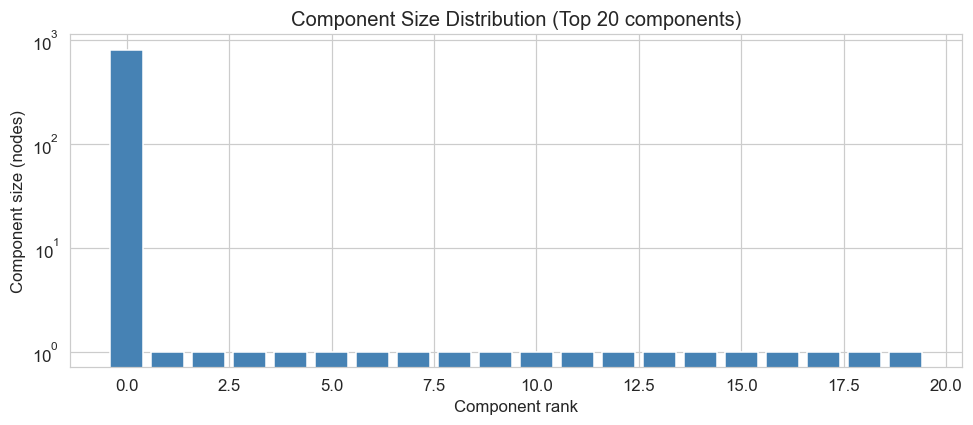

In [60]:
# Giant Connected Component analysis
components = sorted(nx.connected_components(G), key=len, reverse=True)
gcc_nodes  = components[0]
G_gcc      = G.subgraph(gcc_nodes).copy()

print('=== Connected Components ===')
print(f'Total components:       {len(components)}')
print(f'GCC size (nodes):       {len(gcc_nodes):,} ({100*len(gcc_nodes)/G.number_of_nodes():.1f}% of all nodes)')
print(f'GCC edges:              {G_gcc.number_of_edges():,}')
print(f'2nd largest component:  {len(components[1]) if len(components) > 1 else 0} nodes')

# Component size distribution
comp_sizes = [len(c) for c in components]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(min(20, len(comp_sizes))), sorted(comp_sizes, reverse=True)[:20],
       color='steelblue', edgecolor='white')
ax.set_xlabel('Component rank')
ax.set_ylabel('Component size (nodes)')
ax.set_title('Component Size Distribution (Top 20 components)')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('d1_components.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Deliverable 5 — Network Growth Analysis Over Time

We build **yearly cumulative snapshots** of the co-watch network using the first-air year of each anime. At each year *t*, we include all anime that aired by year *t* and all co-watch edges between them. We track how the network's topology evolved and identify whether a **percolation threshold** exists — a tipping point where the giant component rapidly absorbed isolated clusters.

**Metrics tracked per year:**
- Giant component fraction
- Number of nodes and edges
- Average degree
- Average clustering coefficient
- Modularity

In [61]:
# Map anime_id -> air_year in the co-watch network
anime_year_map = {}
for node in G.nodes():
    yr = G.nodes[node].get('year', np.nan)
    if pd.notna(yr):
        anime_year_map[node] = int(yr)

years_in_network = sorted(set(anime_year_map.values()))
print(f'Anime with known air years in network: {len(anime_year_map)}')
print(f'Year range in network: {min(years_in_network)} – {max(years_in_network)}')

# Restrict to 1995–2020 (main growth period)
YEAR_START = 1995
YEAR_END   = 2020
years_range = list(range(YEAR_START, YEAR_END + 1))

# Pre-compute all edges with both endpoints having known years
edges_with_years = []
for u, v in G.edges():
    yu = anime_year_map.get(u)
    yv = anime_year_map.get(v)
    if yu is not None and yv is not None:
        edges_with_years.append((u, v, max(yu, yv)))  # edge available when BOTH have aired

print(f'Edges with known years: {len(edges_with_years):,}')
print(f'Building {len(years_range)} yearly snapshots...')

Anime with known air years in network: 1000
Year range in network: 1984 – 2020
Edges with known years: 43,844
Building 26 yearly snapshots...


In [62]:
# Build yearly cumulative snapshots and track metrics
snapshot_metrics = []

for yr in years_range:
    # Nodes: all anime that aired by this year
    nodes_yr = [n for n, y in anime_year_map.items() if y <= yr]
    # Edges: co-watch edges where both anime aired by this year
    edges_yr = [(u, v) for u, v, ey in edges_with_years if ey <= yr]

    if len(nodes_yr) < 3:
        continue

    Gyr = nx.Graph()
    Gyr.add_nodes_from(nodes_yr)
    Gyr.add_edges_from(edges_yr)

    n_nodes = Gyr.number_of_nodes()
    n_edges = Gyr.number_of_edges()
    if n_nodes == 0:
        continue

    comps = sorted(nx.connected_components(Gyr), key=len, reverse=True)
    gcc_frac = len(comps[0]) / n_nodes
    avg_deg  = 2 * n_edges / n_nodes if n_nodes > 0 else 0
    avg_clust = nx.average_clustering(Gyr) if n_edges > 0 else 0

    # Modularity (skip if too slow)
    mod = np.nan
    if n_nodes <= 500 and n_edges > 0:
        try:
            from networkx.algorithms.community import greedy_modularity_communities
            comm_yr = list(greedy_modularity_communities(Gyr))
            mod = nx.community.modularity(Gyr, comm_yr)
        except:
            pass

    snapshot_metrics.append({
        'year': yr,
        'n_nodes': n_nodes,
        'n_edges': n_edges,
        'gcc_frac': gcc_frac,
        'avg_degree': avg_deg,
        'avg_clustering': avg_clust,
        'modularity': mod,
        'n_components': len(comps),
    })

metrics_df = pd.DataFrame(snapshot_metrics)
print('Snapshot metrics computed.')
print(metrics_df.tail(10).to_string(index=False))

Snapshot metrics computed.
 year  n_nodes  n_edges  gcc_frac  avg_degree  avg_clustering  modularity  n_components
 2011      467     8694  0.747323   37.233405        0.588112    0.122392           119
 2012      549    12558  0.770492   45.748634        0.607173         NaN           127
 2013      623    16634  0.781701   53.399679        0.628721         NaN           137
 2014      710    22246  0.785915   62.664789        0.633556         NaN           153
 2015      788    28739  0.798223   72.941624        0.646769         NaN           160
 2016      854    34000  0.802108   79.625293        0.651775         NaN           170
 2017      908    37821  0.806167   83.306167        0.657658         NaN           177
 2018      953    40805  0.806925   85.634837        0.660520         NaN           185
 2019      983    43444  0.811801   88.390641        0.666359         NaN           186
 2020     1000    43844  0.808000   87.688000        0.664176         NaN           193


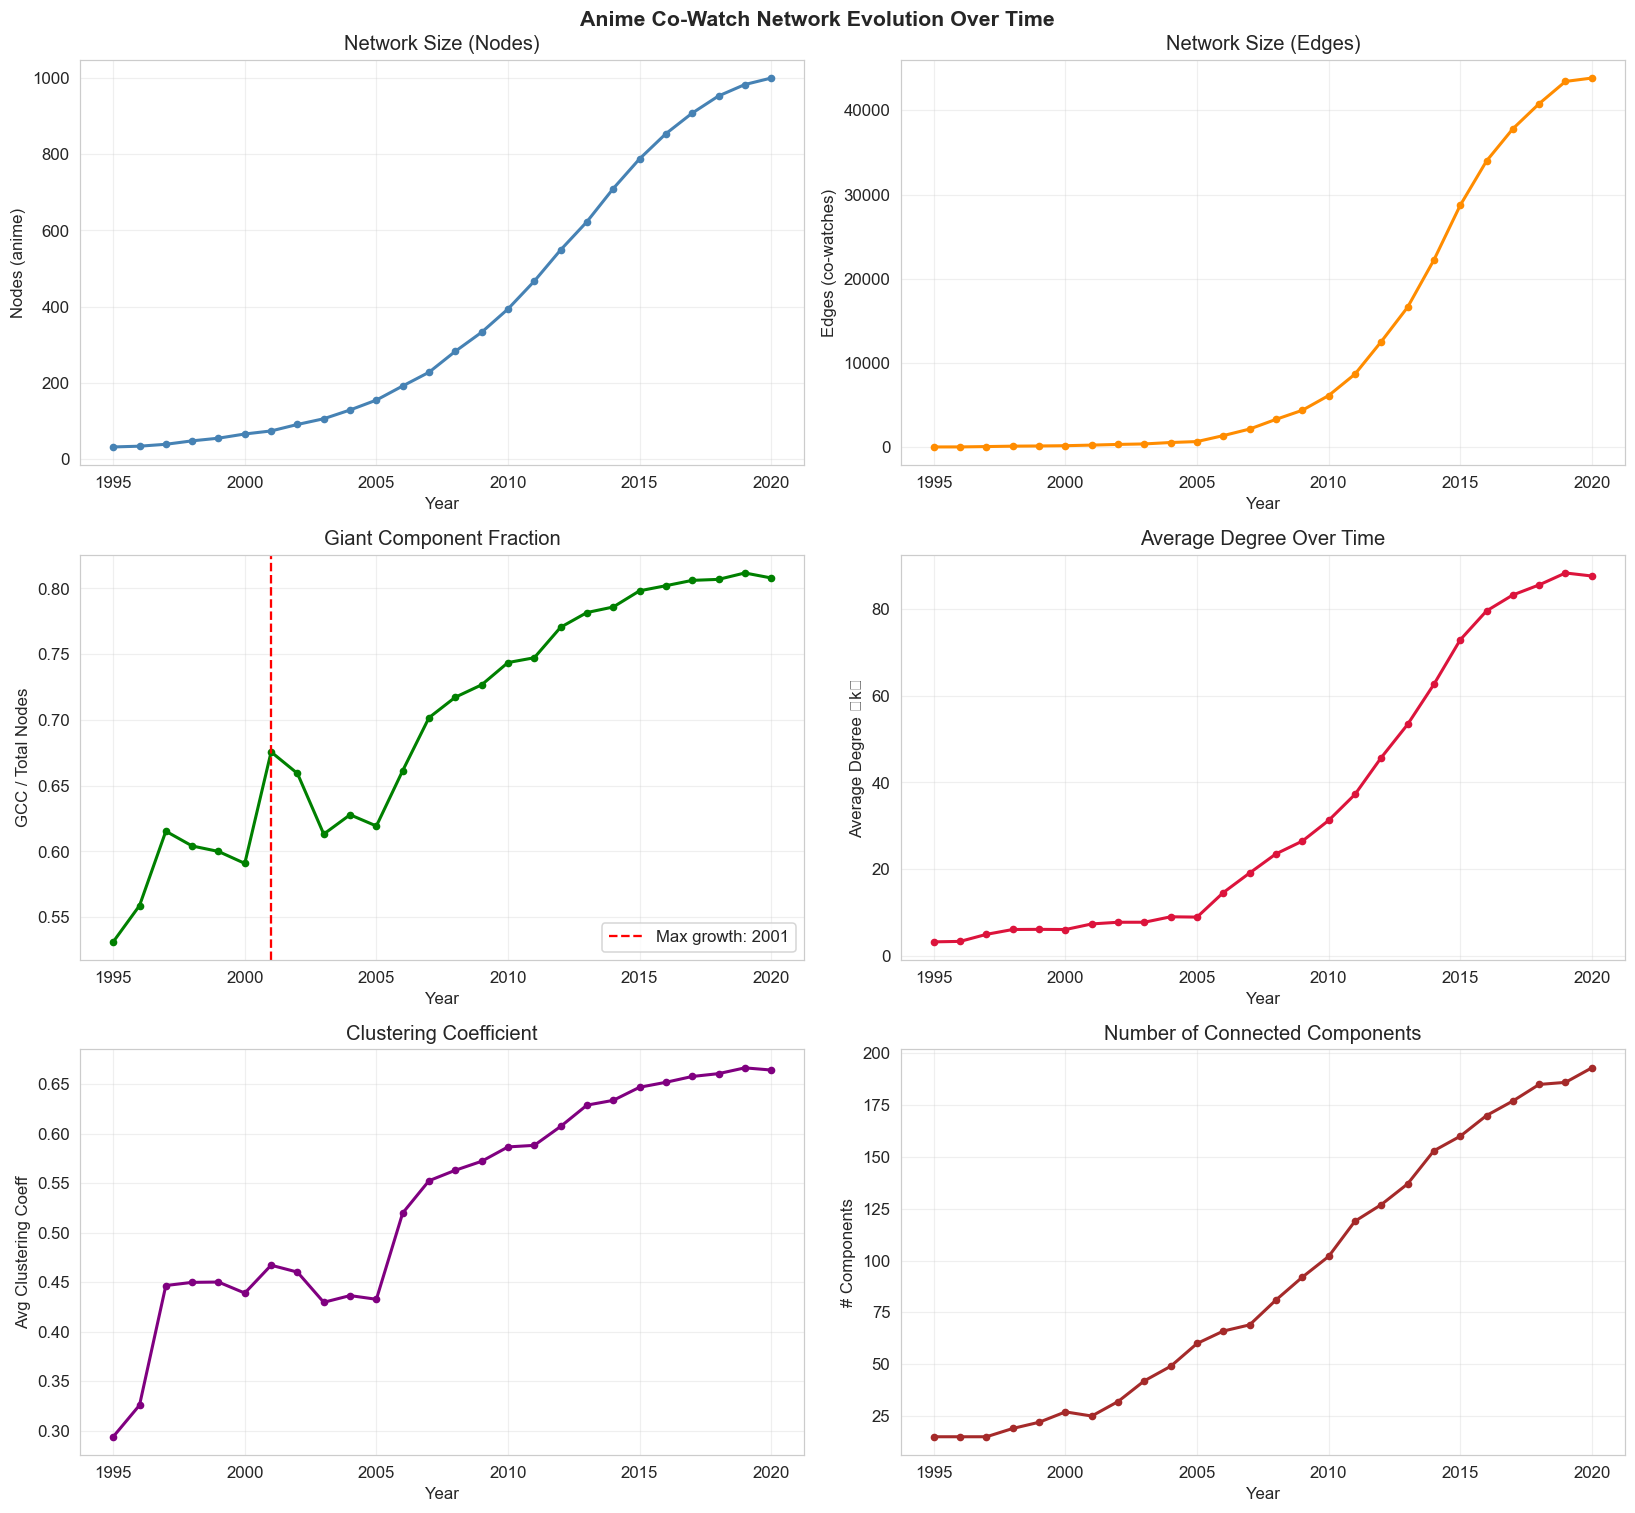

Largest single-year GCC growth at: 2001


In [63]:
# Time series plots of network evolution
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

def plot_metric(ax, col, ylabel, title, color='steelblue'):
    sub = metrics_df.dropna(subset=[col])
    ax.plot(sub['year'], sub[col], '-o', color=color, markersize=4, linewidth=2)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plot_metric(axes[0][0], 'n_nodes',       'Nodes (anime)',        'Network Size (Nodes)',          'steelblue')
plot_metric(axes[0][1], 'n_edges',       'Edges (co-watches)',   'Network Size (Edges)',          'darkorange')
plot_metric(axes[1][0], 'gcc_frac',      'GCC / Total Nodes',    'Giant Component Fraction',      'green')
plot_metric(axes[1][1], 'avg_degree',    'Average Degree ⟨k⟩',  'Average Degree Over Time',      'crimson')
plot_metric(axes[2][0], 'avg_clustering','Avg Clustering Coeff', 'Clustering Coefficient',        'purple')
plot_metric(axes[2][1], 'n_components',  '# Components',         'Number of Connected Components','brown')

# Mark percolation-like transition on GCC plot
gcc_series = metrics_df[['year','gcc_frac']].dropna()
gcc_diff   = gcc_series['gcc_frac'].diff().abs()
if len(gcc_diff) > 0:
    peak_idx = gcc_diff.idxmax()
    peak_year = gcc_series.loc[peak_idx, 'year']
    axes[1][0].axvline(peak_year, color='red', linestyle='--', linewidth=1.5,
                       label=f'Max growth: {peak_year:.0f}')
    axes[1][0].legend()

plt.suptitle('Anime Co-Watch Network Evolution Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('d5_temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Largest single-year GCC growth at: {peak_year:.0f}')

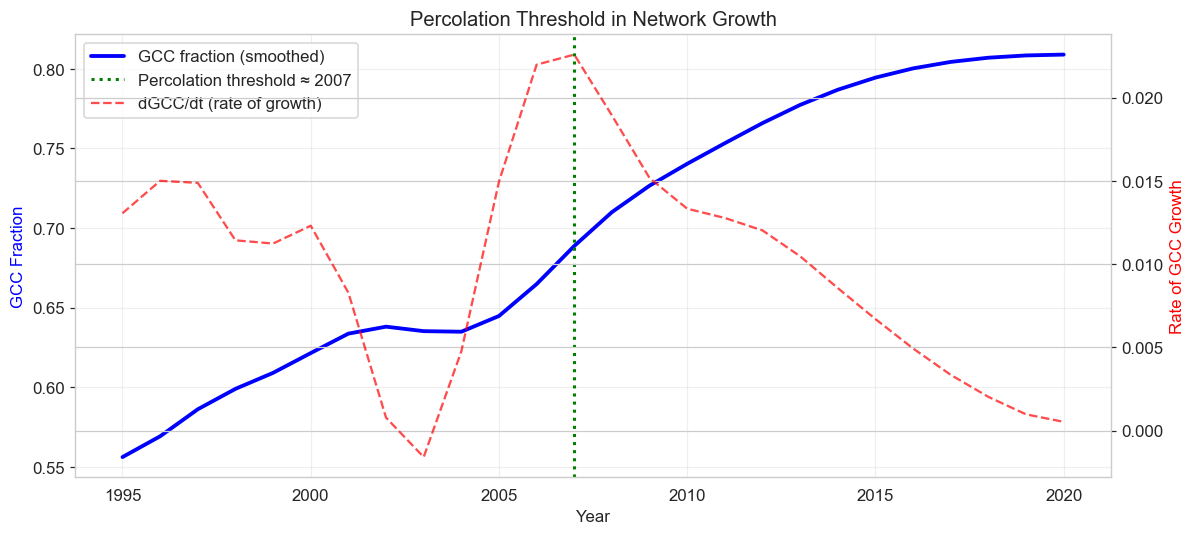

Estimated percolation threshold year: 2007
At threshold: 228 nodes, 2177 edges, avg_degree=19.10, GCC=0.702


In [64]:
# Identify percolation threshold more precisely
# The percolation threshold is where GCC / N jumps most sharply
gcc_s = metrics_df[['year','gcc_frac','avg_degree']].dropna(subset=['gcc_frac'])

# Smooth and find derivative peak
from scipy.ndimage import gaussian_filter1d
gcc_smooth = gaussian_filter1d(gcc_s['gcc_frac'].values, sigma=1.5)
gcc_deriv  = np.gradient(gcc_smooth)
percolation_year = gcc_s['year'].values[np.argmax(gcc_deriv)]

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(gcc_s['year'], gcc_smooth, 'b-', linewidth=2.5, label='GCC fraction (smoothed)')
ax2.plot(gcc_s['year'], gcc_deriv,  'r--', linewidth=1.5, alpha=0.7, label='dGCC/dt (rate of growth)')

ax1.axvline(percolation_year, color='green', linestyle=':', linewidth=2,
            label=f'Percolation threshold ≈ {int(percolation_year)}')

ax1.set_xlabel('Year')
ax1.set_ylabel('GCC Fraction', color='blue')
ax2.set_ylabel('Rate of GCC Growth', color='red')
ax1.set_title('Percolation Threshold in Network Growth')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('d5_percolation_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Estimated percolation threshold year: {int(percolation_year)}')
row = metrics_df[metrics_df['year'] == percolation_year].iloc[0] if len(metrics_df[metrics_df['year'] == percolation_year]) > 0 else None
if row is not None:
    print(f'At threshold: {row["n_nodes"]:.0f} nodes, {row["n_edges"]:.0f} edges, avg_degree={row["avg_degree"]:.2f}, GCC={row["gcc_frac"]:.3f}')

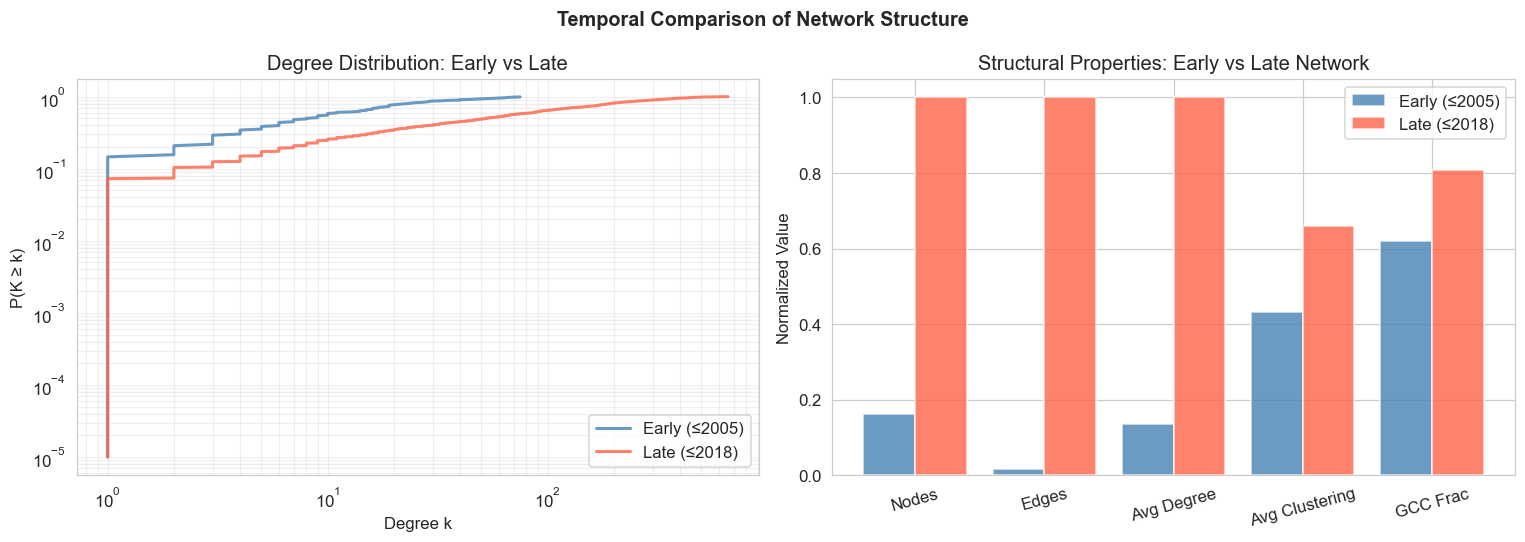

Early network (≤2005):  155 nodes, 690 edges, avg_k=14.38
Late  network (≤2018): 953 nodes, 40805 edges, avg_k=106.12

Power-law exponent γ  early: 1.997  |  late: 1.898
A decreasing γ over time → network becomes more scale-free as it grows.


In [65]:
# Degree distribution comparison: early vs late network
EARLY_CUTOFF = int(percolation_year) - 2 if not np.isnan(percolation_year) else 2002
LATE_CUTOFF  = 2018

# Early network
early_nodes = [n for n, y in anime_year_map.items() if y <= EARLY_CUTOFF]
early_edges = [(u, v) for u, v, ey in edges_with_years if ey <= EARLY_CUTOFF]
G_early = nx.Graph(); G_early.add_nodes_from(early_nodes); G_early.add_edges_from(early_edges)

# Late network
late_nodes = [n for n, y in anime_year_map.items() if y <= LATE_CUTOFF]
late_edges = [(u, v) for u, v, ey in edges_with_years if ey <= LATE_CUTOFF]
G_late = nx.Graph(); G_late.add_nodes_from(late_nodes); G_late.add_edges_from(late_edges)

deg_early = [d for _, d in G_early.degree() if d > 0]
deg_late  = [d for _, d in G_late.degree()  if d > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, degs, label, color, period in [
    (axes[0], deg_early, f'Early (≤{EARLY_CUTOFF})', 'steelblue', 'early'),
    (axes[0], deg_late,  f'Late (≤{LATE_CUTOFF})',   'tomato',    'late'),
]:
    sorted_d = sorted(degs, reverse=True)
    ccdf = 1 - np.arange(1, len(sorted_d)+1)/len(sorted_d)
    ax.loglog(sorted_d, ccdf+1e-5, '-', color=color, label=label, alpha=0.8, linewidth=2)

axes[0].set_xlabel('Degree k'); axes[0].set_ylabel('P(K ≥ k)')
axes[0].set_title('Degree Distribution: Early vs Late')
axes[0].legend(); axes[0].grid(True, which='both', alpha=0.3)

# Summary statistics comparison
categories = ['Nodes', 'Edges', 'Avg Degree', 'Avg Clustering', 'GCC Frac']
def gcc_frac(Gx):
    if Gx.number_of_nodes() == 0: return 0
    return len(max(nx.connected_components(Gx), key=len)) / Gx.number_of_nodes()

early_vals = [
    G_early.number_of_nodes(),
    G_early.number_of_edges(),
    np.mean(deg_early) if deg_early else 0,
    nx.average_clustering(G_early) if G_early.number_of_edges() > 0 else 0,
    gcc_frac(G_early),
]
late_vals = [
    G_late.number_of_nodes(),
    G_late.number_of_edges(),
    np.mean(deg_late) if deg_late else 0,
    nx.average_clustering(G_late) if G_late.number_of_edges() > 0 else 0,
    gcc_frac(G_late),
]

x = np.arange(len(categories))
# Normalize for comparison
max_vals = [max(e, l, 1) for e, l in zip(early_vals, late_vals)]
early_norm = [e/m for e, m in zip(early_vals, max_vals)]
late_norm  = [l/m for l, m in zip(late_vals, max_vals)]

axes[1].bar(x - 0.2, early_norm, 0.4, label=f'Early (≤{EARLY_CUTOFF})', color='steelblue', alpha=0.8)
axes[1].bar(x + 0.2, late_norm,  0.4, label=f'Late (≤{LATE_CUTOFF})',   color='tomato',    alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(categories, rotation=15)
axes[1].set_ylabel('Normalized Value')
axes[1].set_title('Structural Properties: Early vs Late Network')
axes[1].legend()

plt.suptitle('Temporal Comparison of Network Structure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d5_early_vs_late.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Early network (≤{EARLY_CUTOFF}):  {G_early.number_of_nodes()} nodes, {G_early.number_of_edges()} edges, avg_k={np.mean(deg_early):.2f}')
print(f'Late  network (≤{LATE_CUTOFF}): {G_late.number_of_nodes()} nodes, {G_late.number_of_edges()} edges, avg_k={np.mean(deg_late):.2f}')

# Power-law exponent comparison
def power_law_gamma(degrees):
    if not degrees: return np.nan
    kmin = max(1, int(np.percentile(degrees, 50)))
    tail = [d for d in degrees if d >= kmin]
    if len(tail) < 3: return np.nan
    return 1 + len(tail) / np.sum(np.log(np.array(tail) / (kmin - 0.5)))

gamma_early = power_law_gamma(deg_early)
gamma_late  = power_law_gamma(deg_late)
print(f'\nPower-law exponent γ  early: {gamma_early:.3f}  |  late: {gamma_late:.3f}')
print('A decreasing γ over time → network becomes more scale-free as it grows.')


=== Genre Evolution Over Time ===


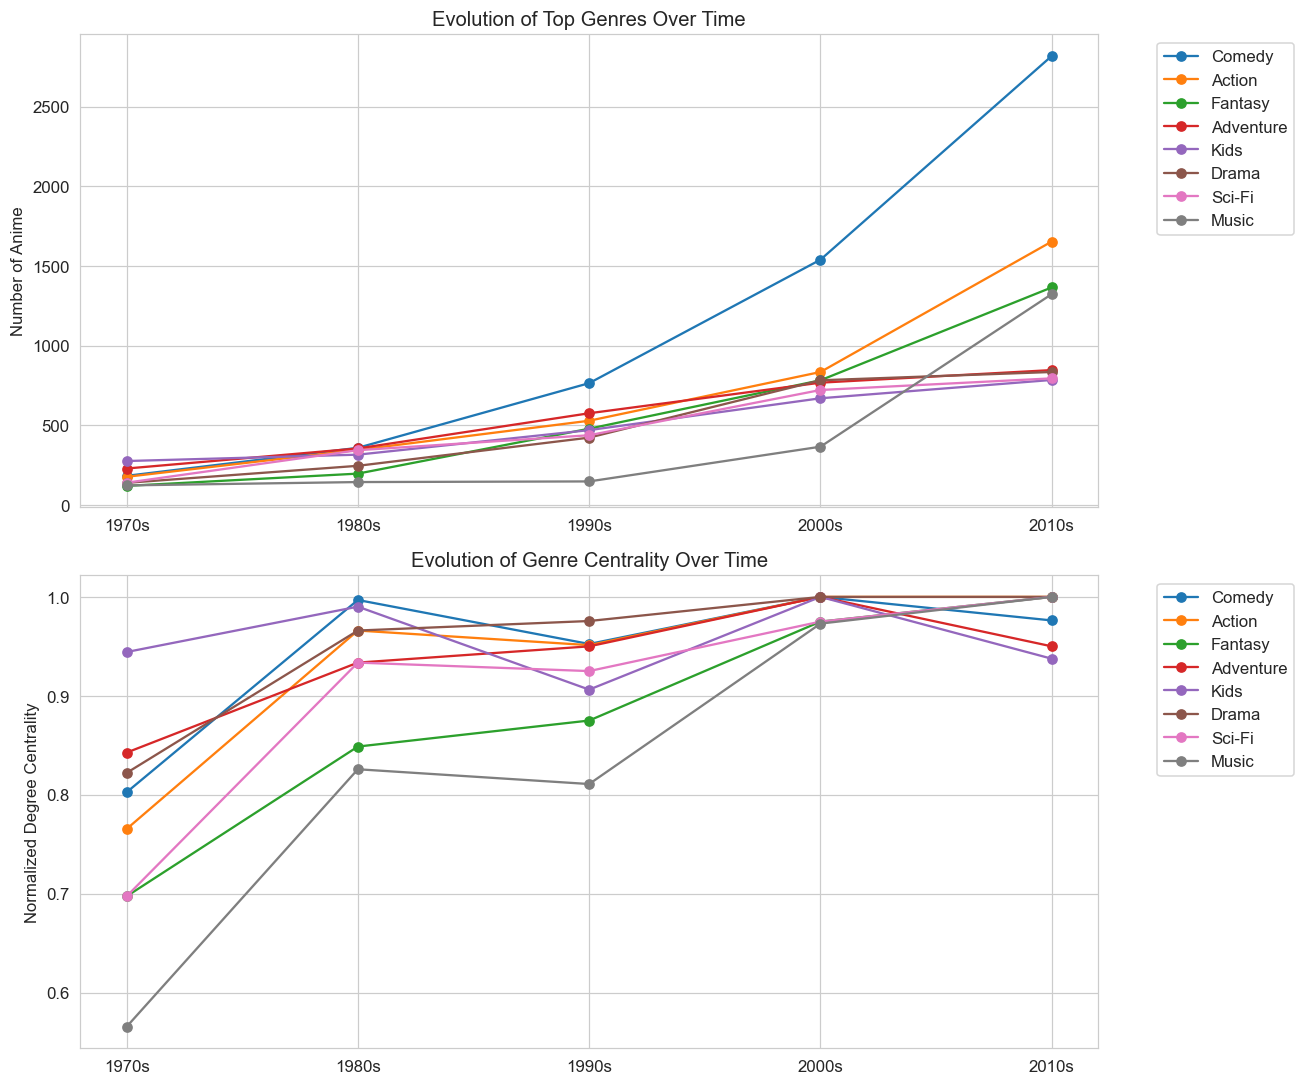

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter, defaultdict

print("\n=== Genre Evolution Over Time ===")

# -----------------------------
# 1. PREPARE DATA (FIXED)
# -----------------------------
anime_df['Year'] = pd.to_numeric(anime_df['air_year'], errors='coerce')

# Remove invalid years
anime_df = anime_df.dropna(subset=['Year'])
anime_df = anime_df[anime_df['Year'] > 1900]

# Time bins
def get_period(year):
    if year < 1980: return '1970s'
    elif year < 1990: return '1980s'
    elif year < 2000: return '1990s'
    elif year < 2010: return '2000s'
    elif year < 2020: return '2010s'
    else: return '2020s'

anime_df['Period'] = anime_df['Year'].apply(get_period)

periods = ['1970s','1980s','1990s','2000s','2010s']

# -----------------------------
# 2. GENRE COUNT OVER TIME
# -----------------------------
period_genre_counts = defaultdict(Counter)

for _, row in anime_df.dropna(subset=['Genres']).iterrows():
    genres = [g.strip() for g in row['Genres'].split(',') if g.strip()]
    for g in genres:
        period_genre_counts[row['Period']][g] += 1

# Top genres overall
all_counts = Counter()
for c in period_genre_counts.values():
    all_counts.update(c)

top_genres = [g for g, _ in all_counts.most_common(8)]

# Build count matrix
count_data = {g: [period_genre_counts[p][g] for p in periods] for g in top_genres}

# -----------------------------
# 3. GENRE CENTRALITY OVER TIME
# -----------------------------
centrality_data = {g: [] for g in top_genres}

for p in periods:
    df_p = anime_df[anime_df['Period'] == p]

    G = nx.Graph()

    for _, row in df_p.dropna(subset=['Genres']).iterrows():
        genres = list(set([g.strip() for g in row['Genres'].split(',') if g.strip()]))

        for g in genres:
            G.add_node(g)

        for i in range(len(genres)):
            for j in range(i+1, len(genres)):
                if G.has_edge(genres[i], genres[j]):
                    G[genres[i]][genres[j]]['weight'] += 1
                else:
                    G.add_edge(genres[i], genres[j], weight=1)

    if len(G) > 0:
        deg_cent = nx.degree_centrality(G)
    else:
        deg_cent = {}

    for g in top_genres:
        centrality_data[g].append(deg_cent.get(g, 0))

# -----------------------------
# 4. NORMALIZE CENTRALITY
# -----------------------------
for g in centrality_data:
    vals = np.array(centrality_data[g])
    if vals.max() > 0:
        centrality_data[g] = vals / vals.max()
    else:
        centrality_data[g] = vals

# -----------------------------
# 5. PLOT
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Plot 1: Genre Counts ---
for g in top_genres:
    axes[0].plot(periods, count_data[g], marker='o', label=g)

axes[0].set_title('Evolution of Top Genres Over Time')
axes[0].set_ylabel('Number of Anime')
axes[0].grid(True)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Plot 2: Centrality ---
for g in top_genres:
    axes[1].plot(periods, centrality_data[g], marker='o', label=g)

axes[1].set_title('Evolution of Genre Centrality Over Time')
axes[1].set_ylabel('Normalized Degree Centrality')
axes[1].grid(True)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('genre_evolution_final.png', dpi=200, bbox_inches='tight')
plt.show()


=== Clean Time-Evolving Anime Network (No Labels) ===


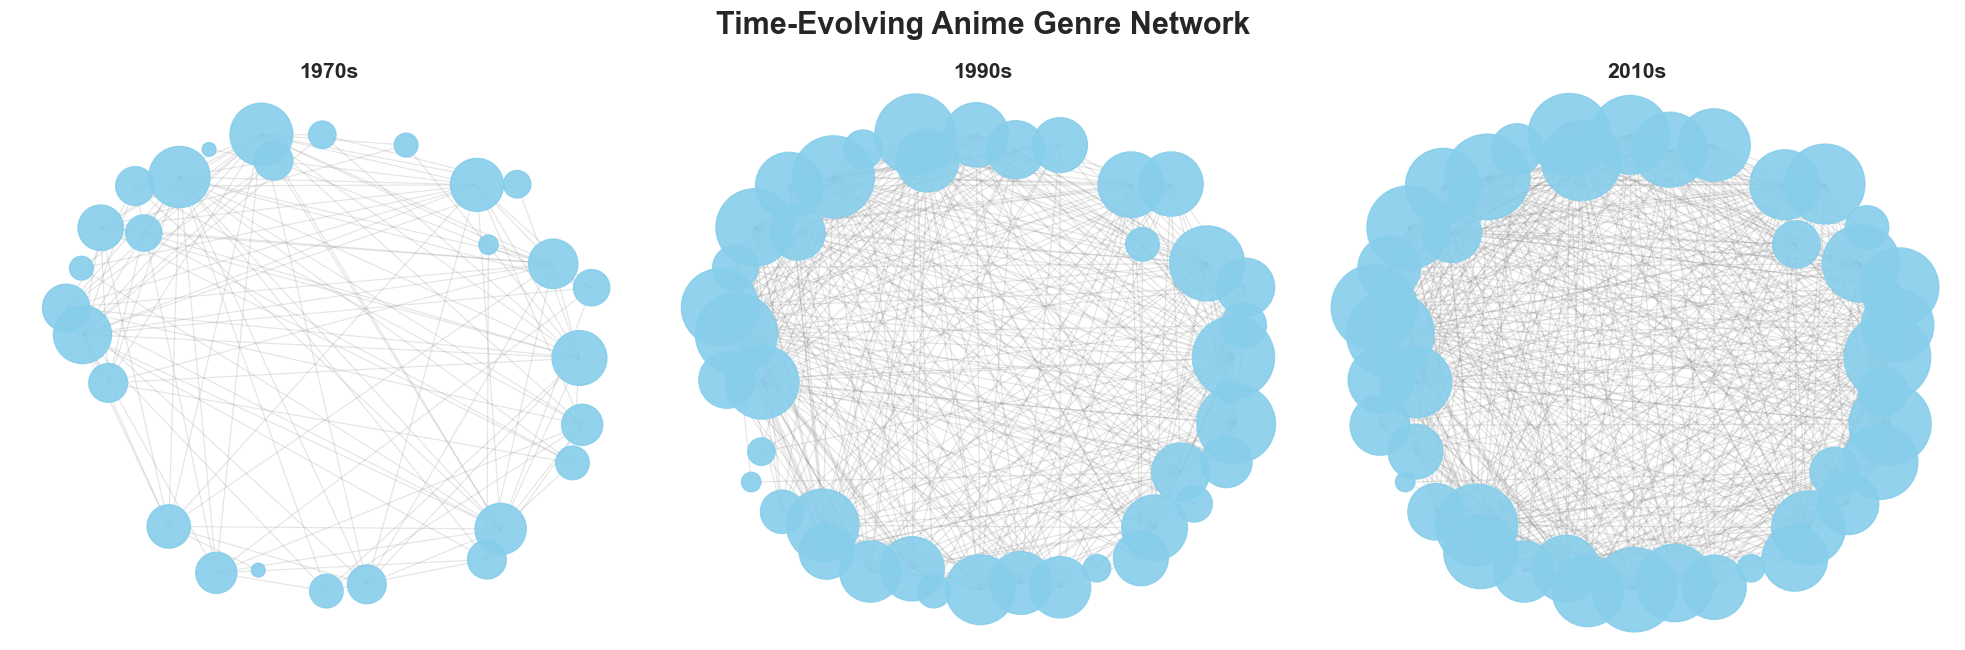

In [71]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

print("\n=== Clean Time-Evolving Anime Network (No Labels) ===")

# -----------------------------
# 1. PREPARE DATA
# -----------------------------
anime_df['Year'] = pd.to_numeric(anime_df['air_year'], errors='coerce')
anime_df = anime_df.dropna(subset=['Year'])

time_slices = {
    "1970s": (1970, 1979),
    "1990s": (1990, 1999),
    "2010s": (2010, 2019)
}

# -----------------------------
# 2. BUILD GRAPH FUNCTION
# -----------------------------
def build_graph(df):
    G = nx.Graph()

    for _, row in df.dropna(subset=['Genres']).iterrows():
        genres = list(set([g.strip() for g in row['Genres'].split(',') if g.strip()]))

        for g in genres:
            G.add_node(g)

        for g1, g2 in combinations(genres, 2):
            if G.has_edge(g1, g2):
                G[g1][g2]['weight'] += 1
            else:
                G.add_edge(g1, g2, weight=1)

    return G

# -----------------------------
# 3. BUILD ALL GRAPHS
# -----------------------------
graphs = {}
all_nodes = set()

for label, (start, end) in time_slices.items():
    df_slice = anime_df[(anime_df['Year'] >= start) & (anime_df['Year'] <= end)]
    G = build_graph(df_slice)

    # Remove weak edges (cleaner graph)
    G.remove_edges_from([
        (u, v) for u, v, d in G.edges(data=True)
        if d['weight'] < 3
    ])

    graphs[label] = G
    all_nodes.update(G.nodes())

# -----------------------------
# 4. FIXED LAYOUT (CONSISTENT)
# -----------------------------
G_all = nx.Graph()
G_all.add_nodes_from(all_nodes)

pos = nx.spring_layout(G_all, seed=42, k=1.2)

# -----------------------------
# 5. PLOT
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, G) in zip(axes, graphs.items()):

    # Node sizes = importance
    node_sizes = [G.degree(n) * 80 for n in G.nodes()]

    # Draw edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        width=0.8,
        alpha=0.2,
        edge_color='gray'
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color='skyblue',
        alpha=0.9
    )

    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.axis('off')

# Title
plt.suptitle("Time-Evolving Anime Genre Network", fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig("anime_time_evolution_no_labels.png", dpi=300)
plt.show()